# PCA / EOF Analysis

Analyse en composantes principales du Fire Weather Index (FWI) sur la grille agrégée 28x28 du sud de l'Espagne (1970-2005).

Deux orientations sont calculées :

- **S-mode** : lignes = temps, colonnes = pixels. Les composantes (EOF) sont des **patterns spatiaux** ; les scores (PC) sont des **séries temporelles**. 
- **T-mode** : lignes = pixels, colonnes = temps. Les composantes sont des **profils temporels** types et les scores sont des cartes de poids par pixel. 

On suit le fil du notebook `PCA.ipynb` (variance expliquée → composantes → projection) en l'adaptant à un champ spatio-temporel.

## Librairies

---

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
import s3fs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

from src.stats.pca_analysis import (
    build_pixel_id,
    aggregate_temporal,
    to_space_time_matrix, to_time_space_matrix,
    clean_matrix,
    run_pca,
    setup_dark_style,
    plot_explained_variance,
    plot_spatial_eof,
    plot_pc_timeseries,
    plot_temporal_modes,
    plot_pixel_loadings,
    compare_modes_variance,
    summary_table,
)

setup_dark_style()

## Chargement des données

---

In [2]:
MY_BUCKET       = "matheo"
CHEMIN_FICHIER  = "diffusion/data"
FICHIER_SMALL   = "fwi_se_spain_28x28.parquet"

fs = s3fs.S3FileSystem(client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"})
with fs.open(f"s3://{MY_BUCKET}/{CHEMIN_FICHIER}/{FICHIER_SMALL}") as f:
    df_small = pd.read_parquet(f)

print(f"De {df_small['time'].min()} à {df_small['time'].max()}")
print(f"Nb lignes : {len(df_small):,}")
df_small.head()

De 1970-01-01 00:00:00 à 2005-12-31 00:00:00
Nb lignes : 10,308,816


,time,lat,lon,fwi-daily-proj
0,1970-01-01,37.267857,-8.548214,1.0
1,1970-01-01,37.267857,-8.244643,1.0
2,1970-01-01,37.267857,-7.941071,1.0
3,1970-01-01,37.267857,-7.637500,1.0
4,1970-01-01,37.267857,-7.333929,1.0


## 1. Mise en forme de la matrice

On part d'une table longue `(time, lat, lon, fwi-daily-proj)` et on construit deux matrices, à des résolutions temporelles différentes :

- **S-mode (journalier)** : `mat_S` de forme `(~13 150 jours, 784 pixels)`. C'est le régime favorable à la PCA (n_obs >> n_var) — pas besoin d'agréger.

- **T-mode (mensuel)** : `mat_T` de forme `(784 pixels, 432 mois)`. Sans agrégation, on aurait `(784, 13 150)` — plus de variables que d'observations. L'agrégation mensuelle (par moyenne) fait ressortir la saisonnalité et la variabilité interannuelle, qui sont les structures temporelles intéressantes à cette résolution.

In [3]:
df_small = df_small.dropna(subset=["fwi-daily-proj"])
df_small = build_pixel_id(df_small)

# S-mode : journalier OK (n_obs=13150 >> n_var=784)
mat_S = clean_matrix(to_space_time_matrix(df_small))

# T-mode : on AGRÈGE AU MOIS avant de pivoter
# Sinon on aurait (784 pixels x 13150 jours), c.-à-d. plus de
# variables que d'observations -> PCA mal posée + bruit haute fréquence.
df_monthly = aggregate_temporal(df_small, freq="MS", agg="mean")
mat_T = clean_matrix(to_time_space_matrix(df_monthly))

print(f"Matrice S-mode journalière (temps x pixels) : {mat_S.shape}")
print(f"Matrice T-mode mensuelle  (pixels x temps) : {mat_T.shape}")

Matrice S-mode journalière (temps x pixels) : (13149, 784)
Matrice T-mode mensuelle  (pixels x temps) : (784, 432)


## 2. PCA en S-mode (EOF spatiales)

On standardise chaque pixel (moyenne 0, variance 1) avant de calculer les composantes.

On garde au plus 50 composantes 

In [4]:
result_S = run_pca(mat_S, n_components=50, standardize=True, mode="S")

print("Variance expliquée par les 10 premières composantes :")
summary_table(result_S, n=10)

Variance expliquée par les 10 premières composantes :


,PC,Variance expliquée (%),Variance cumulée (%)
0,PC1,75.87,75.87
1,PC2,8.46,84.33
2,PC3,3.26,87.59
3,PC4,2.20,89.79
4,PC5,1.01,90.80
5,PC6,0.96,91.76
6,PC7,0.61,92.37
7,PC8,0.50,92.87
8,PC9,0.46,93.33
9,PC10,0.44,93.77


In [5]:
for thr in [0.7, 0.8, 0.9, 0.95]:
    n = result_S.n_components_for(thr)
    print(f"  {int(thr*100)} % de variance : {n} composantes")

  70 % de variance : 1 composantes
  80 % de variance : 2 composantes
  90 % de variance : 5 composantes
  95 % de variance : 15 composantes


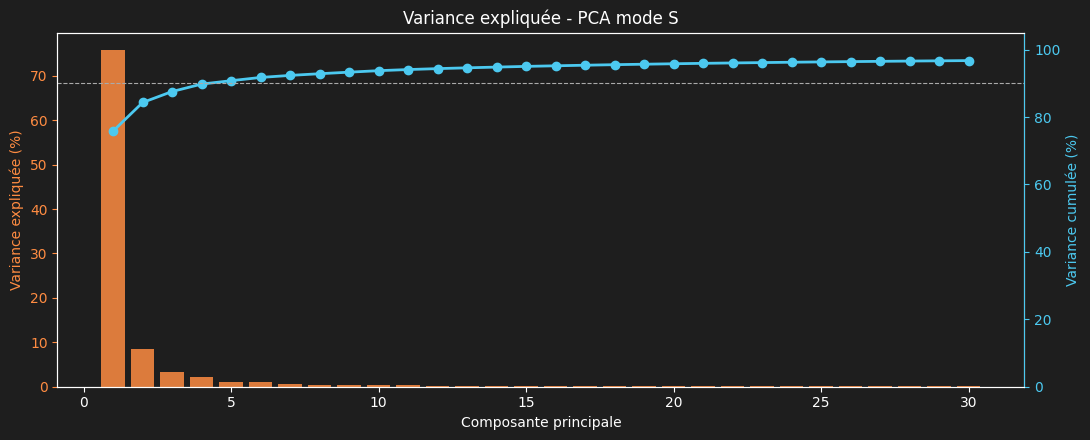

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5), facecolor="#1e1e1e")
plot_explained_variance(result_S, n_show=30, ax=ax)
fig.tight_layout()
fig.savefig("../output/pca_S_explained_variance.png", dpi=200, facecolor="#1e1e1e")
plt.show()

### 2.1 Patterns spatiaux (EOF)

Chaque EOF est un vecteur de dimension 784 que l'on remet en grille 28x28. C'est l'équivalent climatique des *eigenfaces* de PCA :

- **rouge** = corrélation positive avec le score temporel PCk
- **bleu**  = corrélation négative

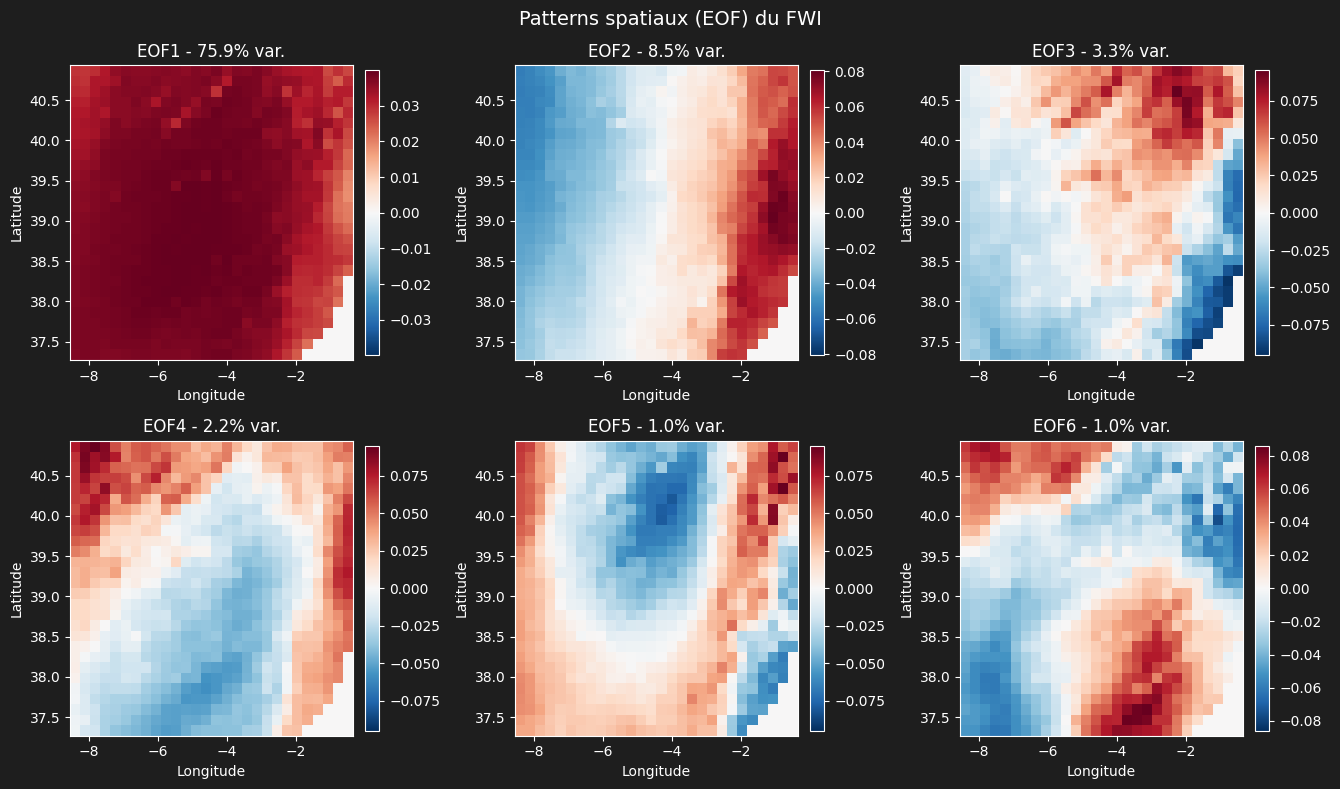

In [7]:
fig = plot_spatial_eof(result_S, n_components=6, ncols=3)
fig.savefig("../output/pca_S_eof_maps.png", dpi=200, facecolor="#1e1e1e", bbox_inches="tight")
plt.show()

### 2.2 Séries temporelles des PC

Les scores donnent, pour chaque jour, le poids de chaque EOF dans le champ FWI observé.

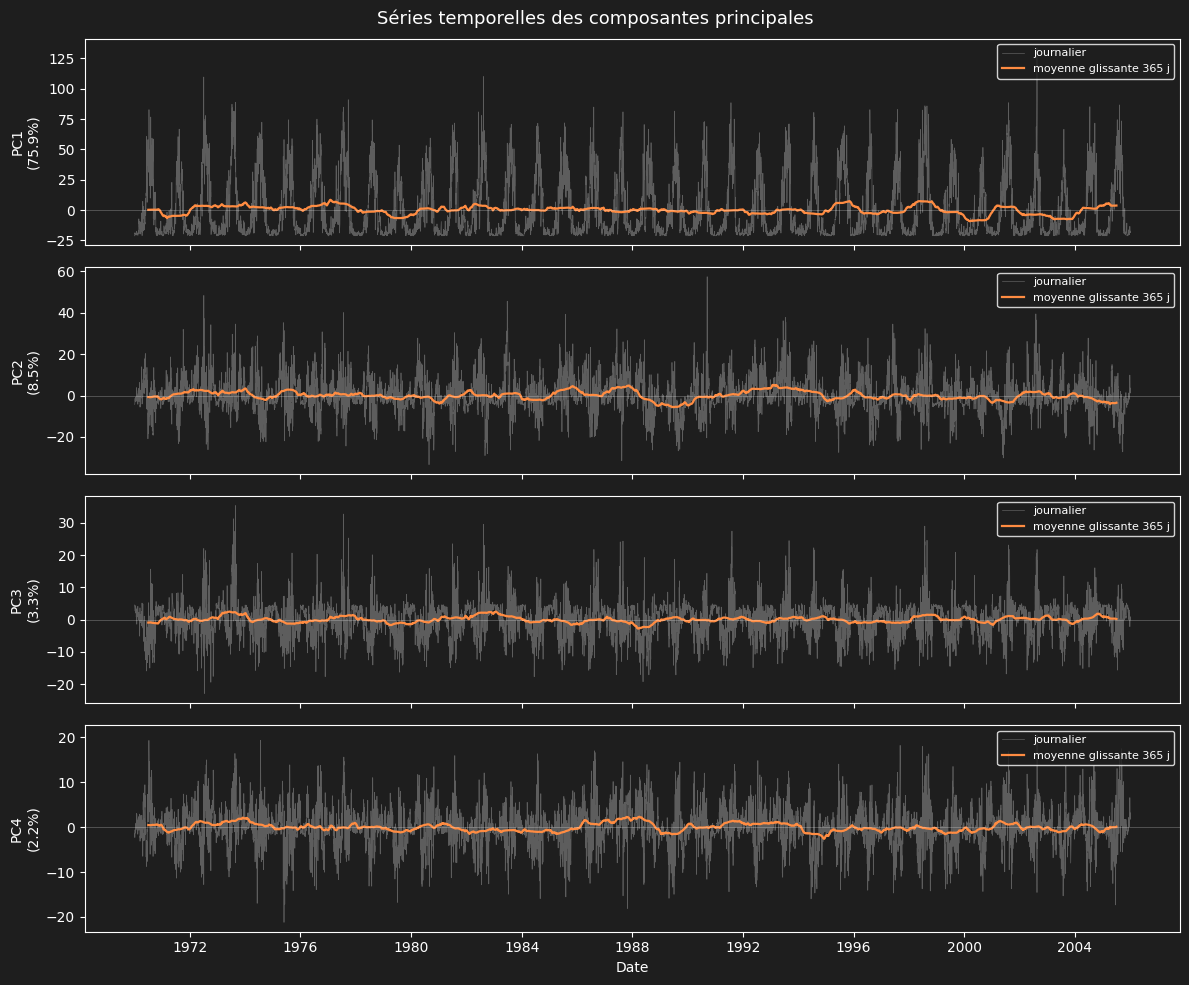

In [8]:
fig = plot_pc_timeseries(result_S, n_components=4, rolling=365)
fig.savefig("../output/pca_S_pc_timeseries.png", dpi=200, facecolor="#1e1e1e", bbox_inches="tight")
plt.show()

### 2.3 Décomposition saisonnière des PC

On regroupe les scores par mois pour vérifier que PC1 capture bien le cycle annuel attendu (FWI haut en été, bas en hiver).

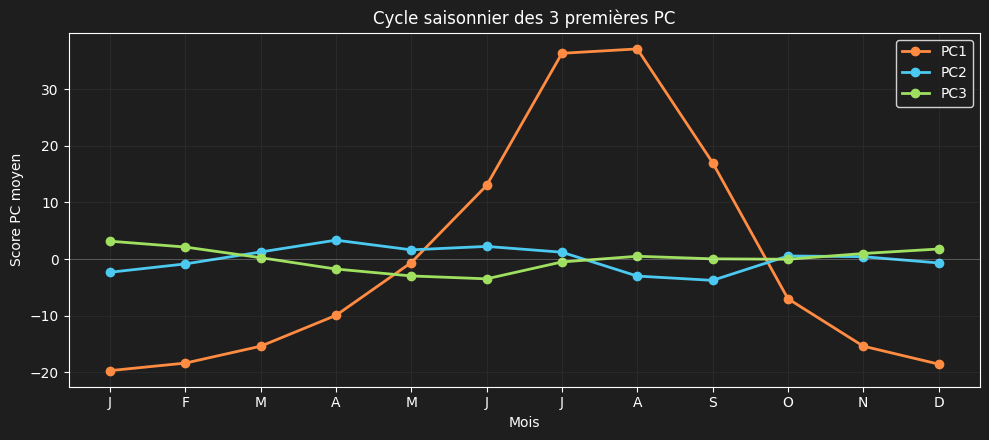

In [9]:
scores = result_S.scores.copy()
scores["month"] = scores.index.month
monthly_pc = scores.groupby("month").mean()

fig, ax = plt.subplots(figsize=(10, 4.5), facecolor="#1e1e1e")
for pc, color in zip(["PC1", "PC2", "PC3"], ["#ff8c42", "#4cc9f0", "#a0e060"]):
    ax.plot(monthly_pc.index, monthly_pc[pc], "o-", label=pc, color=color, linewidth=2)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax.axhline(0, color="white", linewidth=0.4, alpha=0.4)
ax.set_xlabel("Mois")
ax.set_ylabel("Score PC moyen")
ax.set_title("Cycle saisonnier des 3 premières PC")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../output/pca_S_seasonal_cycle.png", dpi=200, facecolor="#1e1e1e")
plt.show()

## 3. PCA en T-mode (modes temporels)

On échange lignes et colonnes : chaque pixel devient une observation décrite par sa série temporelle **mensuelle** (432 valeurs).

Les composantes représentent des **profils temporels types**, et les scores donnent un poids par pixel — qu'on peut recartographier en grille 28x28.

In [10]:
result_T = run_pca(mat_T, n_components=50, standardize=True, mode="T")

print("Variance expliquée par les 10 premières composantes (T-mode) :")
summary_table(result_T, n=10)

Variance expliquée par les 10 premières composantes (T-mode) :


,PC,Variance expliquée (%),Variance cumulée (%)
0,PC1,56.74,56.74
1,PC2,23.45,80.19
2,PC3,4.81,85.00
3,PC4,2.06,87.05
4,PC5,1.91,88.96
5,PC6,1.18,90.14
6,PC7,1.15,91.29
7,PC8,0.80,92.08
8,PC9,0.69,92.78
9,PC10,0.51,93.29


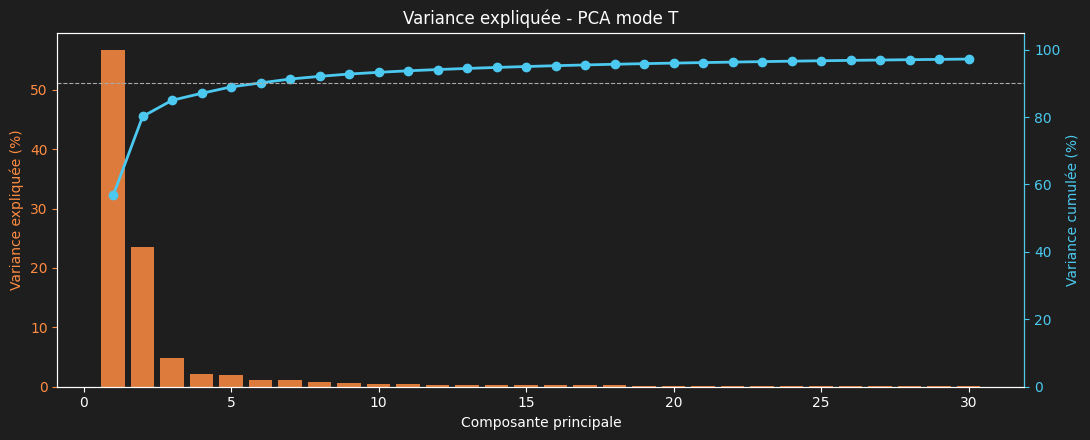

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.5), facecolor="#1e1e1e")
plot_explained_variance(result_T, n_show=30, ax=ax)
fig.tight_layout()
fig.savefig("../output/pca_T_explained_variance.png", dpi=200, facecolor="#1e1e1e")
plt.show()

### 3.1 Profils temporels (modes T)

Chaque mode est une série temporelle de référence 

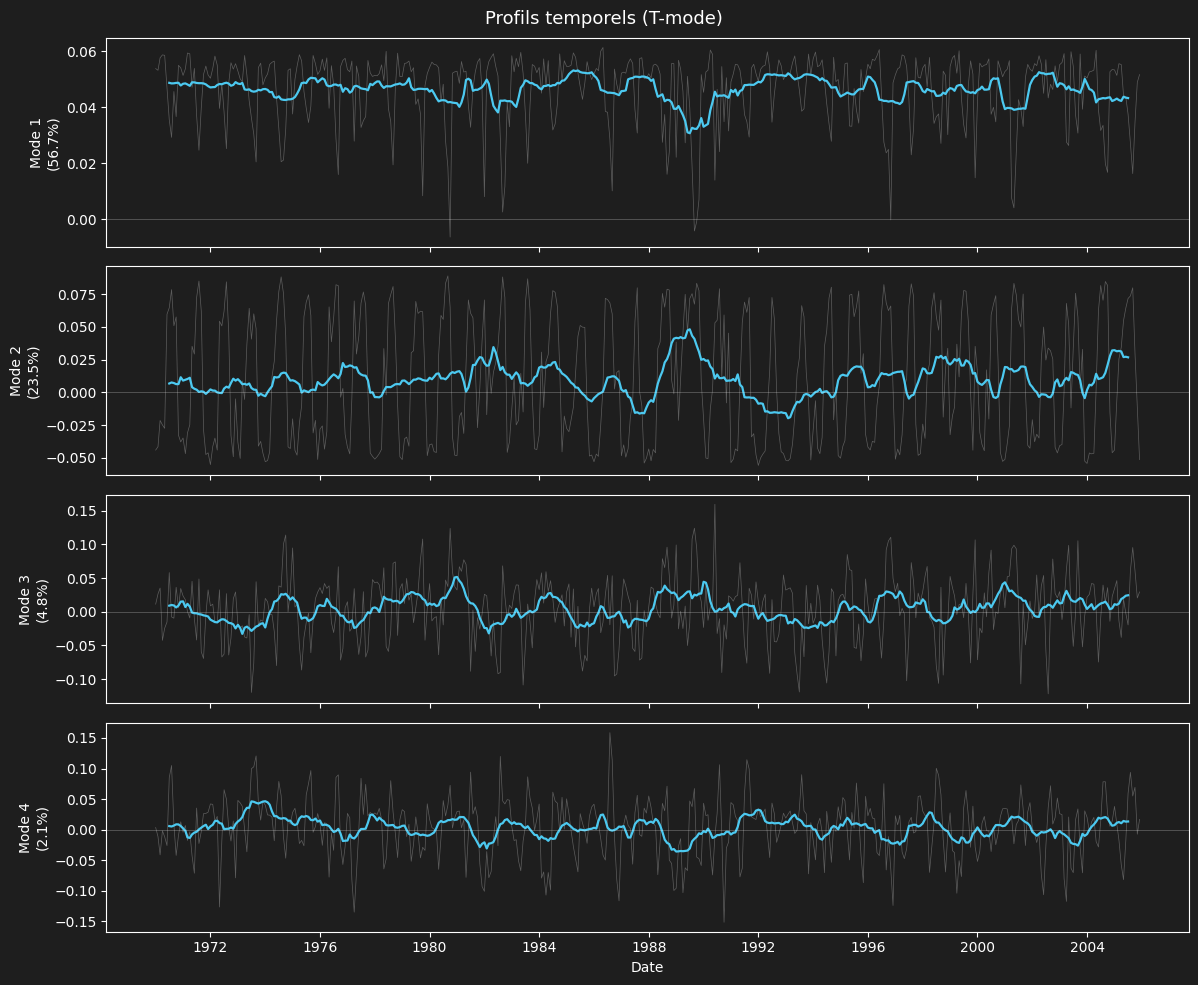

In [12]:
fig = plot_temporal_modes(result_T, n_components=4, rolling=12)
fig.savefig("../output/pca_T_temporal_modes.png", dpi=200, facecolor="#1e1e1e", bbox_inches="tight")
plt.show()

### 3.2 Cartes des poids par pixel

Pour chaque mode, on trace la carte des scores : un pixel rouge ressemble fortement au profil temporel, un pixel bleu y est anti-corrélé. On voit ainsi quelles régions partagent un même comportement temporel.

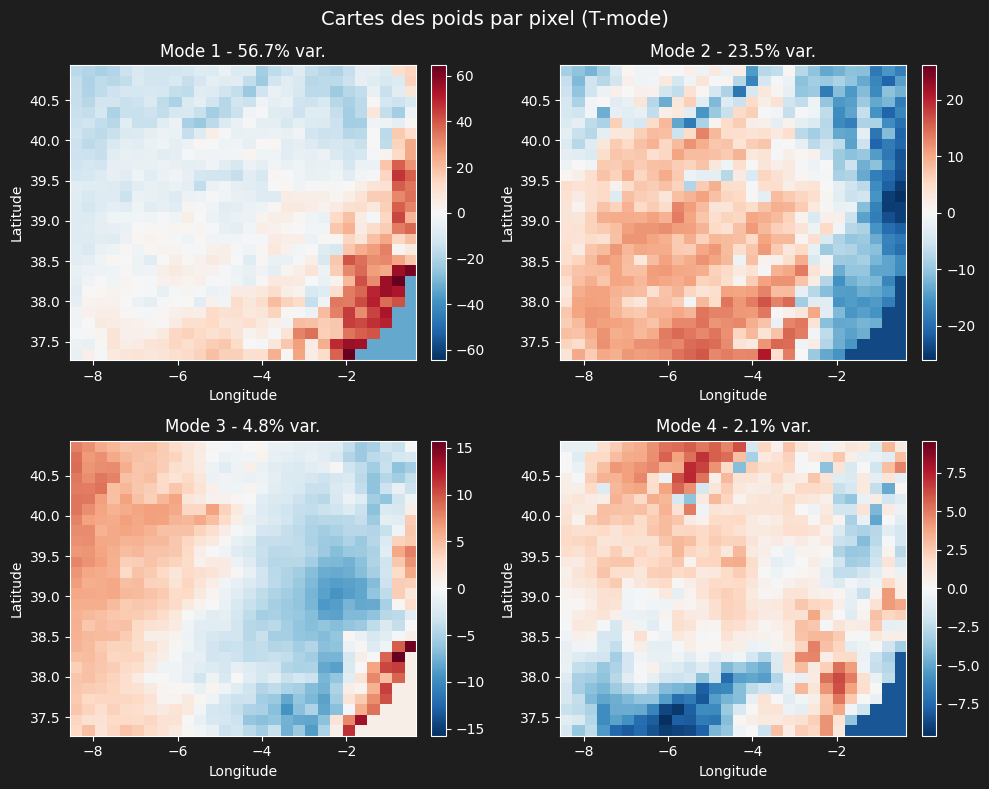

In [13]:
fig = plot_pixel_loadings(result_T, n_components=4, ncols=2)
fig.savefig("../output/pca_T_pixel_loadings.png", dpi=200, facecolor="#1e1e1e", bbox_inches="tight")
plt.show()

## 4. Comparaison S-mode vs T-mode

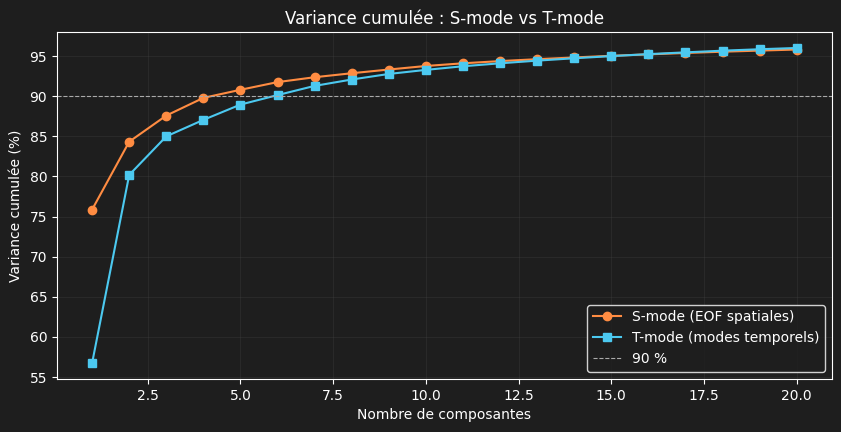

In [14]:
fig = compare_modes_variance(result_S, result_T, n_show=20)
fig.savefig("../output/pca_compare_modes.png", dpi=200, facecolor="#1e1e1e", bbox_inches="tight")
plt.show()

## 5. Reconstruction et erreur de troncature

Combien de composantes faut-il garder pour reconstruire fidèlement le champ ? On reconstruit la matrice à partir des `k` premières PC et on mesure le RMSE par rapport à l'original.

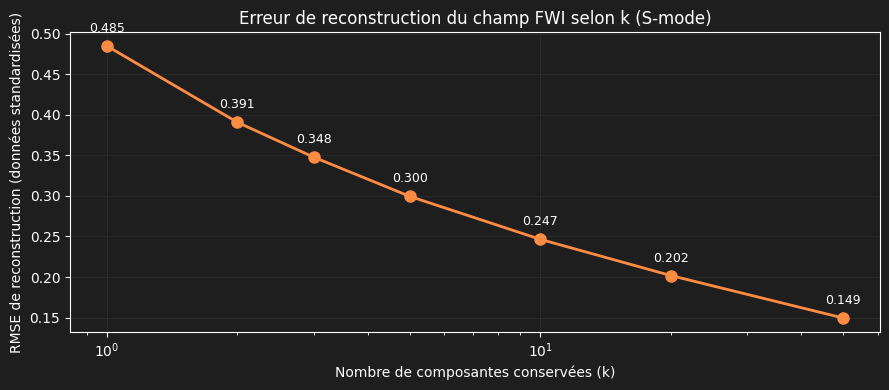

In [15]:
X = mat_S.values
X_centered = X - X.mean(axis=0)
if result_S.scaler is not None:
    X_proc = result_S.scaler.transform(X)
else:
    X_proc = X_centered

ks = [1, 2, 3, 5, 10, 20, 50]
errors = []
for k in ks:
    Xk = result_S.scores.values[:, :k] @ result_S.components.values[:k, :]
    rmse = np.sqrt(np.mean((X_proc - Xk) ** 2))
    errors.append(rmse)

fig, ax = plt.subplots(figsize=(9, 4), facecolor="#1e1e1e")
ax.plot(ks, errors, "o-", color="#ff8c42", linewidth=2, markersize=8)
ax.set_xscale("log")
ax.set_xlabel("Nombre de composantes conservées (k)")
ax.set_ylabel("RMSE de reconstruction (données standardisées)")
ax.set_title("Erreur de reconstruction du champ FWI selon k (S-mode)")
ax.grid(alpha=0.3)
for k, e in zip(ks, errors):
    ax.annotate(f"{e:.3f}", (k, e), textcoords="offset points",
                xytext=(0, 10), ha="center", color="white", fontsize=9)
fig.tight_layout()
fig.savefig("../output/pca_reconstruction_error.png", dpi=200, facecolor="#1e1e1e")
plt.show()